> **⚠️ 2026-07-05d amendment (post-review).** The §4 "F closed / physical floor" verdict was
> **partially overstated**: the 10.2% overlap disagreement quoted below is the RAW value — after
> the minnaert correction it is **4.0%** (worst pairs 0.7–4%), yet predictions still differ ~20%
> even where corrected inputs agree to <1%. The real floor = embedder amplification (no
> cross-frame loss term) + one anomalous frame — both addressable. The **input-mapping leg**
> remains closed, but a Phase-2 invariance & leveling docket (H1–H6) is now open:
> PLAN_StripingArtifact "PHASE 2", DECISIONS 2026-07-05d,
> `reports/f_leg_b/review_overlap_residual.csv`. Everything else in this notebook stands.


# 28 — F verdict: skill preserved, artifact NOT removed → F closed

**The question F was meant to answer.** The regional abundance map shows a rectangular
"striping" artifact: adjacent CTX **source frames** in the Murray mosaic carry slightly different
radiometry, and the texture model amplifies those invisible differences into visible blocks
(notebook 25; η² 0.011 vs 0.002 null). **Mitigation F** = skip the mosaic, run inference directly
on ISIS-`ctxcal`-calibrated CTX source frames (physical I/F, no per-frame mosaic stretch), on the
bet that calibrated frames agree well enough to remove the blocks at source.

**F has to clear two independent bars**, and this notebook consolidates both:

| test | measures | result |
|---|---|---|
| **Skill gate** (LOIO, notebook 27) | within-scene rich/poor ranking | **PASS** (Δ median +0.0067) |
| **η² artifact test** (this notebook) | same-ground agreement ACROSS frames | **FAIL** (η² 0.179; blocks visible) |

They are *different failure modes*, and F splits them: it preserves skill but does not remove the
artifact. Below: how the mapping iteration got to the skill PASS (§1–2), the decisive η² test
(§3), and why F is closed (§4).


In [1]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(REPO))
import src.modeling  # noqa: F401  OpenMP bootstrap; must precede numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

FIG = REPO / "reports" / "figures"
LEGB = REPO / "reports" / "f_leg_b"

variant = pd.read_csv(LEGB / "variant_summary.csv", index_col=0)
eta = pd.read_csv(FIG / "f_pilot_eta2_summary.csv")
print(f"variant table: {variant.shape[0]} images × {variant.shape[1]} columns")
print(f"eta2 rows (minnaert_log): {len(eta)}")


variant table: 36 images × 8 columns
eta2 rows (minnaert_log): 3


## §1 — The skill gate: five mappings to a PASS

Leg B first FAILED with the perframe mapping (−0.0499; notebook 27). Diagnostics pointed at the
I/F→uint8 **mapping**, not F itself, so we iterated the mapping family (all on the same retrained
embeddings, same LOIO folds, same 36 common images). The gate is Δ median per-image AUC ≥ −0.02
vs the mosaic baseline (0.786).


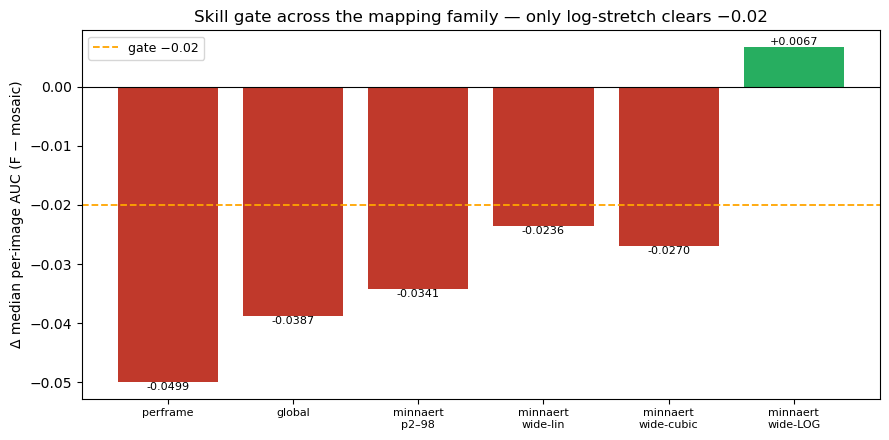

win/loss vs baseline per variant:
  perframe         Δmed -0.0499  win 11  loss 25  below0.5 8
  global           Δmed -0.0387  win 11  loss 25  below0.5 1
  minn_p2_98       Δmed -0.0341  win 14  loss 22  below0.5 2
  minn_wide_lin    Δmed -0.0236  win 16  loss 20  below0.5 2
  minn_wide_cubic  Δmed -0.0270  win 17  loss 19  below0.5 2
  minn_wide_LOG    Δmed +0.0067  win 18  loss 18  below0.5 3


In [2]:
# Δ median AUC per variant, computed from the per-image table
base_med = variant["baseline"].median()
order = ["perframe", "global", "minn_p2_98", "minn_wide_lin", "minn_wide_cubic", "minn_wide_LOG"]
labels = ["perframe", "global", "minnaert\np2–98", "minnaert\nwide-lin",
          "minnaert\nwide-cubic", "minnaert\nwide-LOG"]
dmed = [variant[c].median() - base_med for c in order]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#27ae60" if d >= -0.02 else "#c0392b" for d in dmed]
bars = ax.bar(range(len(order)), dmed, color=colors)
ax.axhline(-0.02, color="orange", ls="--", lw=1.3, label="gate −0.02")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(order))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Δ median per-image AUC (F − mosaic)")
ax.set_title("Skill gate across the mapping family — only log-stretch clears −0.02")
for i, d in enumerate(dmed):
    ax.annotate(f"{d:+.4f}", (i, d), ha="center",
                va="bottom" if d >= 0 else "top", fontsize=8)
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "28_f_skill_gate_variants.png", dpi=120); plt.show()

print("win/loss vs baseline per variant:")
for c in order:
    d = variant[c] - variant["baseline"]
    print(f"  {c:16s} Δmed {variant[c].median()-base_med:+.4f}  "
          f"win {int((d>0).sum())}  loss {int((d<0).sum())}  below0.5 {int((variant[c]<0.5).sum())}")


**The log domain was the lever.** `ln(I/F)` gives every scene a brightness-independent
texture-DN budget — surface texture is *multiplicative* contrast, which is what the FM's 8-bit
pretraining expects. It is the only variant to pass (Δ median **+0.0067**, pooled PR-AUC +0.017 —
F actually *exceeds* the mosaic). Two things it is NOT:
- **Not cubic resampling.** minnaert-wide with cubic extract (−0.027) scored *worse* than bilinear
  (−0.024), so the ~40%-high-frequency-texture deficit measured earlier is not the skill cap. The
  blur hypothesis is closed.
- **Not a metadata fluke** — though we did find and fix one: SeamMap listed frame P20_008839's
  incidence as 4.28° (a decimal-shift of the true 42.76°, verified against the PDS volume index).
  Re-sourcing all 81 frames' incidence from PDS confirmed SeamMap is otherwise correct to <0.2°.


## §2 — Why the skill PASS was not the end

The skill gate measures **within-scene ranking** — can the model order rich vs poor tiles inside
one image. It says nothing about whether the *same ground*, imaged by two different overlapping
frames, gets the *same* prediction. That cross-frame agreement IS the striping artifact, and it is
what F was built to fix. So the PASS was necessary but not sufficient; the decisive test is η².


## §3 — The η² artifact test (decisive)

Leg A measured η² with the *mosaic-trained* head (invalid — OOD on calibrated frames). Here we use
the head **trained on the log-minnaert F embeddings** (`train_deployable_head.py --store-name
fang_embeddings_f_minnaert_wl`, 36 images), run it on the **7 overlapping E8_N44 pilot frames**
(same crop as the mosaic baselines), and measure how much prediction variance is explained by
*which frame* a cell came from. Low η² = block-free; the mosaic baselines on this crop are raw
**0.196** / A1 **0.141**; target ≲ 0.03.


In [3]:
ml = eta[eta.mapping == "minnaert_log"].set_index("composite")["eta2"]
comparison = pd.DataFrame([
    {"pipeline": "mosaic raw",              "eta2_median": 0.196, "skill_delta": np.nan, "cost": "free"},
    {"pipeline": "F log-minnaert (retrained)","eta2_median": float(ml["median"]),
     "skill_delta": +0.0067, "cost": "~333 CPU-h"},
    {"pipeline": "A1 (mosaic per-frame o+g)","eta2_median": 0.141, "skill_delta": -0.024, "cost": "~free"},
    {"pipeline": "target (block-free)",      "eta2_median": 0.03,  "skill_delta": np.nan, "cost": "—"},
])
print(comparison.to_string(index=False))
print(f"\nF η² by composite:  partition {ml['partition']:.3f}  "
      f"eroded {ml['partition_eroded']:.3f}  median {ml['median']:.3f}")
print("overlap agreement:  I/F |ratio−1| = 10.2%   →   prediction |diff| = 20.4%  (embedder ~2× amplify)")


                  pipeline  eta2_median  skill_delta       cost
                mosaic raw       0.1960          NaN       free
F log-minnaert (retrained)       0.1794       0.0067 ~333 CPU-h
 A1 (mosaic per-frame o+g)       0.1410      -0.0240      ~free
       target (block-free)       0.0300          NaN          —

F η² by composite:  partition 0.277  eroded 0.278  median 0.179
overlap agreement:  I/F |ratio−1| = 10.2%   →   prediction |diff| = 20.4%  (embedder ~2× amplify)


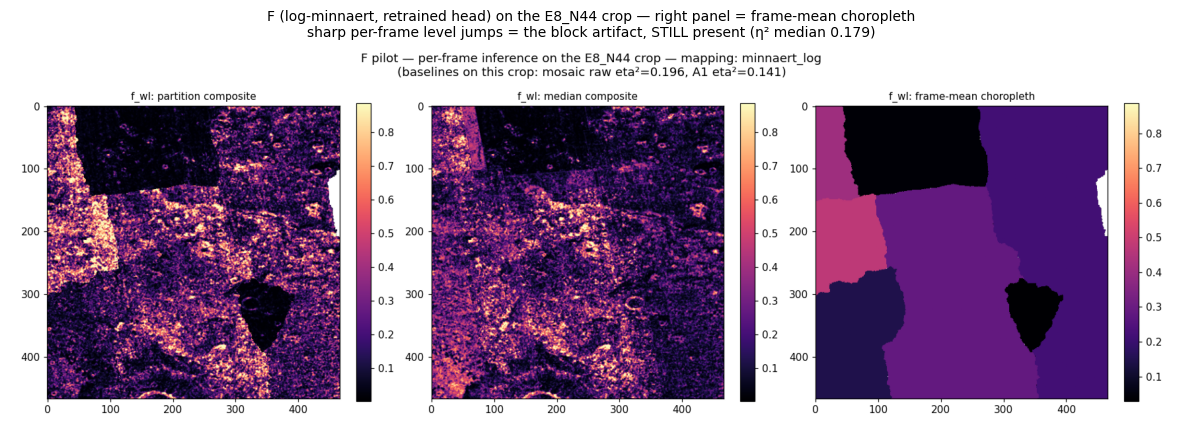

In [4]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.imshow(mpimg.imread(FIG / "f_pilot_minnaert_log.png")); ax.axis("off")
ax.set_title("F (log-minnaert, retrained head) on the E8_N44 crop — right panel = frame-mean "
             "choropleth\nsharp per-frame level jumps = the block artifact, STILL present "
             "(η² median 0.179)", fontsize=10)
plt.show()


**η² = 0.179 (median composite), 0.277 (partition) — blocks plainly visible.** Only 9% below
mosaic-raw (0.196), and *worse* than the near-free A1 fix (0.141). The retrained head barely moved
η² because it was trained on within-image ranking, so it never learned — and cannot learn —
between-frame invariance when the **inputs themselves still disagree by ~10%**.


## §4 — Verdict: F closed

**F preserves skill but does not remove the artifact.** On η² — F's entire reason for existing — it
is dominated by A1, which is essentially free (a mosaic-side per-frame offset+gain, no ISIS
pipeline). The 907-frame regional ISIS build (~333 CPU-h) is therefore **not justified**.

**Root cause, now firmly established.** The ~10% co-located I/F disagreement between overlapping
frames is **physical**: illumination geometry, emission and phase angle, and atmosphere. The
minnaert correction removes only the incidence component; `ctxcal` + minnaert + log-stretch leave
the rest. A texture embedder amplifies a 10% input difference into ~20% prediction difference, so
η² floors near ~0.18 for per-frame inference and near ~0.14 for even aggressive per-frame
normalization (A1). **The striping artifact is not a mosaic-construction artifact and cannot be
removed by swapping the mosaic for calibrated per-frame inference.** It is a property of applying a
sensitive texture model to per-frame radiometry that legitimately varies with viewing/illumination.

**What F did settle (kept for the record):**
- The mapping recipe that maximizes skill on calibrated frames: minnaert (k≈0.58, incidence from
  PDS), pooled p0.5–p99.5 **log** stretch, bilinear resample — Δ median +0.0067 vs mosaic.
- The blur/HF-texture-deficit hypothesis is refuted (cubic did not help).
- A reusable retrained-head η² harness (`f_pilot_crop.py --mapping minnaert_log --head-dir …`).

**Status: paused for write-up.** The striping mitigation decision (ship A1 / accept the artifact
with a documented caveat / pursue output-side destriping "E") is deferred. Full record: DECISIONS
2026-07-05b (skill PASS) and 2026-07-05c (η² FAIL); PLAN_StripingArtifact leg-B bullets.
